In [43]:
sovi_vars = [
    "QPOVTY", "QCVLUN", "QED12LES", "QFHH", "QESL", "QAGEDEP", "QFEMALE",
    "QFEMLBR", "QRICH", "QSERV", "QEXTRCT", "QMOHO", "QNOAUTO",
    "MDGRENT", "MDHSEVAL", "PPUNIT", "QRENTER", "QSSBEN", "QHSEBRDN",
    "MEDAGE", "PERCAP", "QBLACK", "QASIAN", "QHISP", "QFAM", "QNOHLTH"
]

In [ ]:
# Just some ideas I had for comparing the effectiveness of SoVI quartiles versus k-means with 
# 4 clusters, per our Feb 19 meeting discussion about "why clustering"

In [51]:
import pandas as pd
import geopandas as gpd
from statsmodels.formula.api import ols

# 1. Processing 2010-2019 with yearly quartiles
all_dfs = []
for yr in range(2010, 2020):
    s = gpd.read_file(f"../data/sovi_data/optimized_sovi/sovi-optimized_{yr}.gpkg")
    k = gpd.read_file(f"../data/testing_data/k-means4/K4-sovi_{yr}.gpkg")
    
    s['sovi_quartile'] = pd.qcut(s['SoVI_Score'], 4, labels=[1, 2, 3, 4])
    
    merged = s[['GEOID', 'sovi_quartile'] + sovi_vars].merge(
        k[['GEOID', 'vulnerability_rank']], on='GEOID'
    )
    all_dfs.append(merged)

df = pd.concat(all_dfs, ignore_index=True)

# 2. Calculate R2 for every single variable
res_list = []
for v in sovi_vars:
    r2_s = ols(f"{v} ~ C(sovi_quartile)", data=df).fit().rsquared
    r2_k = ols(f"{v} ~ C(vulnerability_rank)", data=df).fit().rsquared
    res_list.append({
        'Variable': v, 
        'SoVI_R2': r2_s, 
        'KMeans_R2': r2_k,
    })

# 3. Display as a clean table
df_results = pd.DataFrame(res_list).sort_values('SoVI_R2', ascending=False)
print(df_results.to_string(index=False))

# 4. Global average for context
print(f"\nMean SoVI R2: {df_results['SoVI_R2'].mean():.4f}")
print(f"Mean KMeans R2: {df_results['KMeans_R2'].mean():.4f}")

Variable  SoVI_R2  KMeans_R2
    QFHH 0.387357   0.574659
  PERCAP 0.313220   0.665478
MDHSEVAL 0.296677   0.573048
QED12LES 0.290341   0.456649
  QPOVTY 0.237181   0.574354
   QRICH 0.236079   0.533444
 QNOHLTH 0.228808   0.398220
    QFAM 0.225311   0.572810
  QBLACK 0.196566   0.622464
   QSERV 0.190850   0.399096
QHSEBRDN 0.190619   0.550536
  QCVLUN 0.176554   0.393790
  QSSBEN 0.166982   0.395729
 QFEMALE 0.161611   0.053625
 QNOAUTO 0.144825   0.522957
 QAGEDEP 0.143045   0.165617
   QHISP 0.136727   0.440460
 QEXTRCT 0.124337   0.295849
    QESL 0.119151   0.431249
   QMOHO 0.102944   0.504094
 QRENTER 0.101465   0.518383
 QFEMLBR 0.098158   0.133767
  QASIAN 0.088264   0.304784
  MEDAGE 0.068496   0.411484
 MDGRENT 0.067793   0.414367
  PPUNIT 0.046762   0.011093

Mean SoVI R2: 0.1746
Mean KMeans R2: 0.4199


In [ ]:
# Based on OLS, k-means is better at creating interpretable clusters of data. 
# Maybe we try removing variables with low R2 and seeing how that improves the clustering and PCA algorithms?

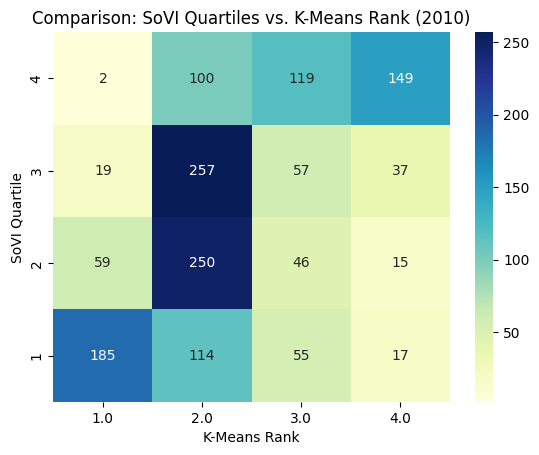

In [44]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt

year = 2010

# Read data
df_s = gpd.read_file(f"../data/sovi_data/optimized_sovi/sovi-optimized_{year}.gpkg")
df_k = gpd.read_file(f"../data/testing_data/k-means4/K4-sovi_{year}.gpkg")

# Create quartile labels (1 to 4) based on the score
# 1 = Lowest vulnerability, 4 = Highest vulnerability
df_s['sovi_quartile'] = pd.qcut(df_s['SoVI_Score'], 4, labels=[1, 2, 3, 4]).astype(int)

# Merge the two dataframes on GEOID
df_compare = df_s[['GEOID', 'sovi_quartile']].merge(
    df_k[['GEOID', 'vulnerability_rank']], 
    on='GEOID'
)

# 1. Generate frequency table
comparison_matrix = pd.crosstab(
    df_compare['sovi_quartile'], 
    df_compare['vulnerability_rank'],
    rownames=['SoVI Quartile'], 
    colnames=['K-Means Rank']
)

comparison_matrix_flipped = comparison_matrix.iloc[::-1]
sns.heatmap(comparison_matrix_flipped, annot=True, fmt="d", cmap="YlGnBu")

# Formatting
plt.title(f"Comparison: SoVI Quartiles vs. K-Means Rank ({year})")
plt.xlabel("K-Means Rank")
plt.ylabel("SoVI Quartile")
plt.show()

